# Homework Module 2
07/10/2026

In [1]:
import pandas as pd
import numpy as np

# Getting the data

In [113]:
df = pd.read_csv("./../../module_1/data/car_fuel_efficiency_2026.csv")
df.head(10)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
5,2007,USA,Hybrid,Front-wheel drive,2,2290,6,266.0,4260,18.8,31.2
6,1992,Asia,Gasoline,Front-wheel drive,2,2270,6,250.0,4310,21.7,26.8
7,2005,USA,Gasoline,Front-wheel drive,4,2370,6,279.0,4090,17.4,30.2
8,1997,Asia,Gasoline,Rear-wheel drive,3,2330,6,251.0,4230,19.5,30.9
9,2004,USA,Diesel,All-wheel drive,5,2330,6,280.0,4620,17.7,31.2


# Preparing the dataset

In [114]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [115]:
df_filter = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df_filter.head(10)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
5,2290,266.0,4260,2007,31.2
6,2270,250.0,4310,1992,26.8
7,2370,279.0,4090,2005,30.2
8,2330,251.0,4230,1997,30.9
9,2330,280.0,4620,2004,31.2


# Exploratory data analysis

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

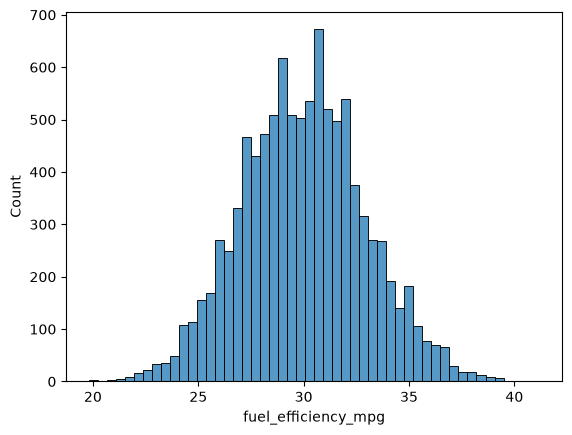

In [117]:
sns.histplot(df_filter['fuel_efficiency_mpg'], bins=50)

## Question 1
There's one column with missing values. What is it?

In [118]:
df_filter

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [119]:
df_filter.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2
What's the median (50% percentile) for variable 'horsepower'?

In [120]:
df_filter['horsepower'].median()

np.float64(254.0)

# Prepare and split the dataset

In [121]:
n = len(df_filter)

n_test = int(n*0.2)
n_val = int(n*0.2)
n_train = int(n*0.6)

In [122]:
n, n_test, n_val, n_train

(10000, 2000, 2000, 6000)

In [123]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [124]:
df_train = df_filter.loc[idx[:n_train]]
df_val = df_filter.loc[idx[n_train:n_train+n_val]]
df_test = df_filter.loc[idx[n_train+n_val:]]

In [125]:
df_train= df_train.reset_index(drop=True)
df_val= df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

In [126]:
#y_train = np.log1p(df_train['fuel_efficiency_mpg'].values)
#y_val= np.log1p(df_val['fuel_efficiency_mpg'].values)
#y_test = np.log1p(df_test['fuel_efficiency_mpg'].values)

y_train = df_train['fuel_efficiency_mpg'].values
y_val= df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [127]:
# delete because we could accidentally use it.
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

## Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

In [128]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year'], dtype='str')

In [129]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

In [130]:
def prepare_X_fillna(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [131]:
def prepare_X_fillmean(df):
    df_num = df[base]
    expected = df_num["horsepower"].mean()
    df_num["horsepower"] = df_num["horsepower"].fillna(expected)
    X = df_num.values
    return X

In [132]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [133]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

### Results for fill with 0

In [134]:
# Train
X_train = prepare_X_fillna(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X_fillna(df_val)
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.205)

### Results for fill with mean

In [135]:
# Train
X_train = prepare_X_fillmean(df_train)
w0, w = train_linear_regression(X_train, y_train)
# Val
X_val = prepare_X_fillmean(df_val)
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 3)

np.float64(2.202)

In [136]:
# answer: both are equally good

## Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

In [137]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [138]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_fillna(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X_fillna(df_val)
    y_pred = w0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred),4)

    print(r, w0, score)

0 -153.88496188271776 2.2053
0.01 -148.3092124416756 2.2058
0.1 -111.83871039289387 2.2241
1 -32.33186596503113 2.3492
5 -7.772852209995108 2.4094
10 -3.9871164160145085 2.4195
100 -0.40821964884641526 2.4292


In [ ]:
# answer: 0 gives the smallest score value. so the answer is 0

## Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))

In [139]:
scores = []

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    n = len(df_filter)

    n_test = int(n*0.2)
    n_val = int(n*0.2)
    n_train = int(n*0.6)

    np.random.seed(s)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df_filter.loc[idx[:n_train]]
    df_val = df_filter.loc[idx[n_train:n_train+n_val]]
    df_test = df_filter.loc[idx[n_train+n_val:]]

    df_train= df_train.reset_index(drop=True)
    df_val= df_val.reset_index(drop=True)
    df_test= df_test.reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val= df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    # delete because we could accidentally use it.
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Train
    X_train = prepare_X_fillna(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    # Val
    X_val = prepare_X_fillna(df_val)
    y_pred = w0 + X_val.dot(w)
    
    score=rmse(y_val, y_pred)
    scores.append(score)
    print(f"seed={s}: RMSE={score}")

seed=0: RMSE=2.239204143052693
seed=1: RMSE=2.202112821083546
seed=2: RMSE=2.1634197787530893
seed=3: RMSE=2.204358876853329
seed=4: RMSE=2.2018800943362384
seed=5: RMSE=2.2457851509078295
seed=6: RMSE=2.269721207951798
seed=7: RMSE=2.1907945999352387
seed=8: RMSE=2.2166112016939774
seed=9: RMSE=2.2070365928242626


In [140]:
# Summary
std = np.std(scores)
print(f"Std:       {std}")
print(f"Std:       {round(std,3)}")

Std:       0.028781274078155564
Std:       0.029


## Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?

In [141]:
n = len(df_filter)

n_test = int(n*0.2)
n_val = int(n*0.2)
n_train = int(n*0.6)

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_filter.loc[idx[:n_train]]
df_val = df_filter.loc[idx[n_train:n_train+n_val]]
df_test = df_filter.loc[idx[n_train+n_val:]]

df_train= df_train.reset_index(drop=True)
df_val= df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val= df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

# delete because we could accidentally use it.
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [142]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

y_full_train = np.concatenate([y_train, y_val])

In [151]:
# Train
X_train = prepare_X_fillna(df_full_train)
w0, w = train_linear_regression_reg(X_train, y_full_train, r=0.001)

# Val
X_test = prepare_X_fillna(df_test)
y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)


In [155]:
print(f"w0={w0}: RMSE={round(score,3)}")

w0=-152.3753577248308: RMSE=2.236
